# Phase 1 – Preprocessing Notebook

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('plots', exist_ok=True)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 1. Upload & Load Dataset
> Download `WA_Fn-UseC_-HR-Employee-Attrition.csv` from Kaggle:  
> https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset  
> Then upload it using the button below.

In [2]:
from google.colab import files
print('Upload the raw dataset CSV file...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = pd.read_csv(filename)
print(f'Dataset loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
df_raw.head()

Upload the raw dataset CSV file...


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv
Dataset loaded: 1470 rows x 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


---
## 2. Initial Data Inspection

In [3]:
print('=== Shape ===')
print(f'{df_raw.shape[0]} rows, {df_raw.shape[1]} columns')

print('\n=== Data Types ===')
print(df_raw.dtypes)

print('\n=== Statistical Summary ===')
df_raw.describe(include='all')

=== Shape ===
1470 rows, 35 columns

=== Data Types ===
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,NaN,2,NaN,NaN,NaN,9,NaN,3,NaN,NaN,NaN,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,NaN,Male,NaN,NaN,NaN,Sales Executive,NaN,Married,NaN,NaN,NaN,Y,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,NaN,882,NaN,NaN,NaN,326,NaN,673,NaN,NaN,NaN,1470,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,2.721769,NaN,65.891156,2.729932,2.063946,NaN,2.728571,NaN,6502.931293,14313.103401,2.693197,NaN,NaN,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,1.093082,NaN,20.329428,0.711561,1.106940,NaN,1.102846,NaN,4707.956783,7117.786044,2.498009,NaN,NaN,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,1.000000,NaN,30.000000,1.000000,1.000000,NaN,1.000000,NaN,1009.000000,2094.000000,0.000000,NaN,NaN,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,2.000000,NaN,48.000000,2.000000,1.000000,NaN,2.000000,NaN,2911.000000,8047.000000,1.000000,NaN,NaN,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,3.000000,NaN,66.000000,3.000000,2.000000,NaN,3.000000,NaN,4919.000000,14235.500000,2.000000,NaN,NaN,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,4.000000,NaN,83.750000,3.000000,3.000000,NaN,4.000000,NaN,8379.000000,20461.500000,4.000000,NaN,NaN,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


---
## 3. CLEANING & PRUNING

### 3.1 — Drop Constant Columns

**Why we do this:**  
Some columns in the IBM HR dataset carry absolutely no information because they have the same value for every single employee. A machine learning model cannot learn anything from a feature that never changes — it contributes zero variance and only adds noise.

**Columns dropped and why:**
- **`EmployeeCount`** — always equals 1. It was included by IBM to count employees in aggregations, not as a predictive feature.
- **`Over18`** — always equals 'Y'. All employees in this dataset are over 18, so this column is meaningless.
- **`StandardHours`** — always equals 80. This represents the standard work week and is the same for everyone.
- **`EmployeeNumber`** — a unique ID assigned to each employee. It has no relationship with attrition; it is just a row identifier.

In [4]:
# Automatically detect constant columns (nunique == 1)
constant_cols = [col for col in df_raw.columns if df_raw[col].nunique() <= 1]
id_cols = ['EmployeeNumber']
cols_to_drop = constant_cols + id_cols

print('=== Columns Being Dropped ===')
for col in cols_to_drop:
    reason = 'Constant — zero variance' if col in constant_cols else 'Unique ID — not a feature'
    print(f'  {col}: {reason} | unique values = {df_raw[col].nunique()}')

df = df_raw.drop(columns=cols_to_drop)
print(f'\nBefore: {df_raw.shape[1]} columns → After: {df.shape[1]} columns')

=== Columns Being Dropped ===
  EmployeeCount: Constant — zero variance | unique values = 1
  Over18: Constant — zero variance | unique values = 1
  StandardHours: Constant — zero variance | unique values = 1
  EmployeeNumber: Unique ID — not a feature | unique values = 1470

Before: 35 columns → After: 31 columns


### 3.2 — Missing Value Analysis

**Why we check this:**  
Missing values can cause errors during model training and can silently bias results if not addressed. We must identify them before any further preprocessing.

**Finding:**  
The IBM HR dataset is a synthetic dataset created by IBM data scientists, so it contains no missing values. However, we still include this check because:
1. It is good practice to always verify — never assume.
2. If this pipeline is ever run on real HR data, the check and the imputation logic in the pipeline will handle missing values automatically.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Count': missing, 'Percent %': missing_pct})
missing_with_values = missing_summary[missing_summary['Count'] > 0]

if missing_with_values.empty:
    print('No missing values found across all 31 columns.')
    print('The IBM HR dataset is complete — no imputation needed.')
else:
    print('Missing values detected:')
    print(missing_with_values)

No missing values found across all 31 columns.
The IBM HR dataset is complete — no imputation needed.


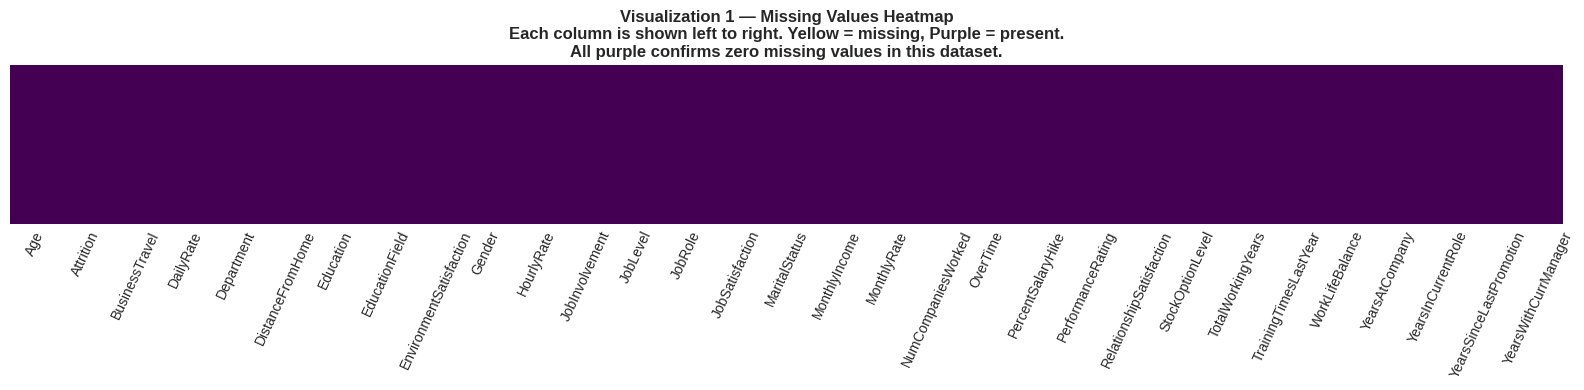

Visualization 1 saved.


In [6]:
# VISUALIZATION 1: Missing Values Heatmap
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax, yticklabels=False)
ax.set_title(
    'Visualization 1 — Missing Values Heatmap\n'
    'Each column is shown left to right. Yellow = missing, Purple = present.\n'
    'All purple confirms zero missing values in this dataset.',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=65)
plt.tight_layout()
plt.savefig('plots/viz1_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 1 saved.')

### 3.3 — Target Variable Encoding: Attrition → Binary (0 / 1)

**Why we do this:**  
The target column `Attrition` is stored as text ('Yes' / 'No'). Machine learning algorithms require numeric inputs, so we convert it to a binary integer:
- `Yes` → `1` (employee left the company)
- `No` → `0` (employee stayed)

**Why we use manual mapping instead of LabelEncoder:**  
LabelEncoder assigns 0/1 alphabetically, which would make `No = 0` and `Yes = 1` — correct in this case, but not guaranteed for all datasets. Using an explicit `.map()` makes our intent clear and removes ambiguity.

In [7]:
print('Before encoding:')
print(df['Attrition'].value_counts())
print(f'Data type: {df["Attrition"].dtype}')

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print('\nAfter encoding:')
print(df['Attrition'].value_counts())
print(f'Data type: {df["Attrition"].dtype}')
print(f'Attrition rate: {df["Attrition"].mean()*100:.1f}% of employees left')

Before encoding:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Data type: object

After encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64
Data type: int64
Attrition rate: 16.1% of employees left


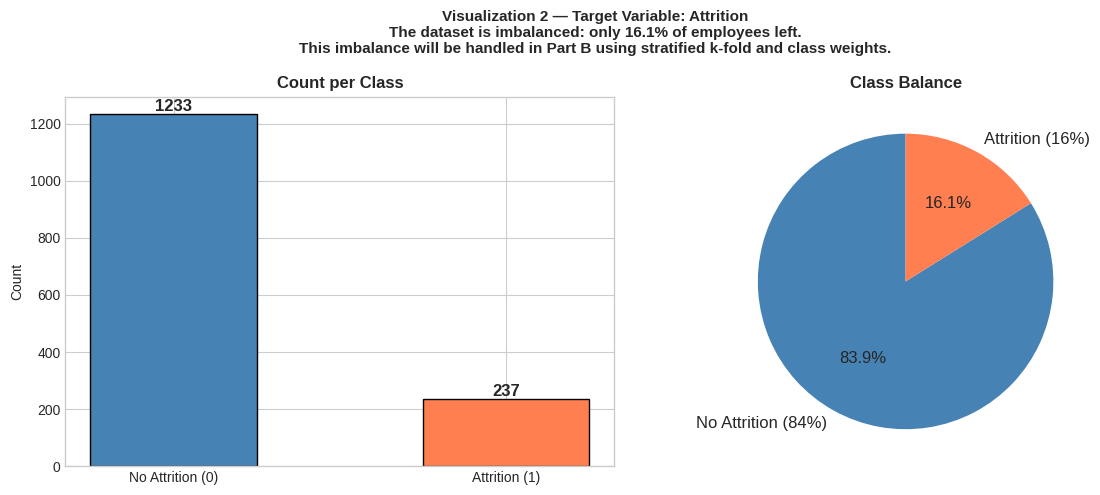

Visualization 2 saved.


In [8]:
# VISUALIZATION 2: Target Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Attrition'].value_counts()
axes[0].bar(['No Attrition (0)', 'Attrition (1)'], counts.values,
            color=['steelblue', 'coral'], edgecolor='black', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Count per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Attrition (84%)', 'Attrition (16%)'],
            colors=['steelblue', 'coral'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=12, fontweight='bold')

plt.suptitle(
    'Visualization 2 — Target Variable: Attrition\n'
    'The dataset is imbalanced: only 16.1% of employees left.\n,
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 2 saved.')

---
## 4. CATEGORICAL DATA — One-Hot Encoding

**Why One-Hot Encoding (OHE)?**  
Some categorical features are **nominal** — they have multiple categories with no natural order or ranking between them. If we assigned numbers directly (e.g., Sales=1, R&D=2, HR=3), the model would wrongly interpret this as R&D being "twice" Sales and HR being "three times" Sales. This would introduce a false numerical relationship that does not exist.

One-Hot Encoding solves this by creating a separate binary column for each category. Each column is either 0 or 1, and no ordering is implied.

**Columns encoded with OHE and why:**

| Column | Categories | Why OHE |
|--------|-----------|--------|
| `Department` | Sales, R&D, HR | No meaningful rank between departments |
| `EducationField` | Life Sciences, Medical, Marketing, etc. | No ordering between fields of study |
| `JobRole` | Manager, Scientist, Technician, etc. | No ordering between job roles |
| `MaritalStatus` | Single, Married, Divorced | No ordering between marital statuses |


In [9]:
ohe_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']

print('=== Unique values per column (confirming they are nominal) ===')
for col in ohe_cols:
    print(f'  {col} ({df[col].nunique()} categories): {sorted(df[col].unique())}')

=== Unique values per column (confirming they are nominal) ===
  Department (3 categories): ['Human Resources', 'Research & Development', 'Sales']
  EducationField (6 categories): ['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']
  JobRole (9 categories): ['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']
  MaritalStatus (3 categories): ['Divorced', 'Married', 'Single']


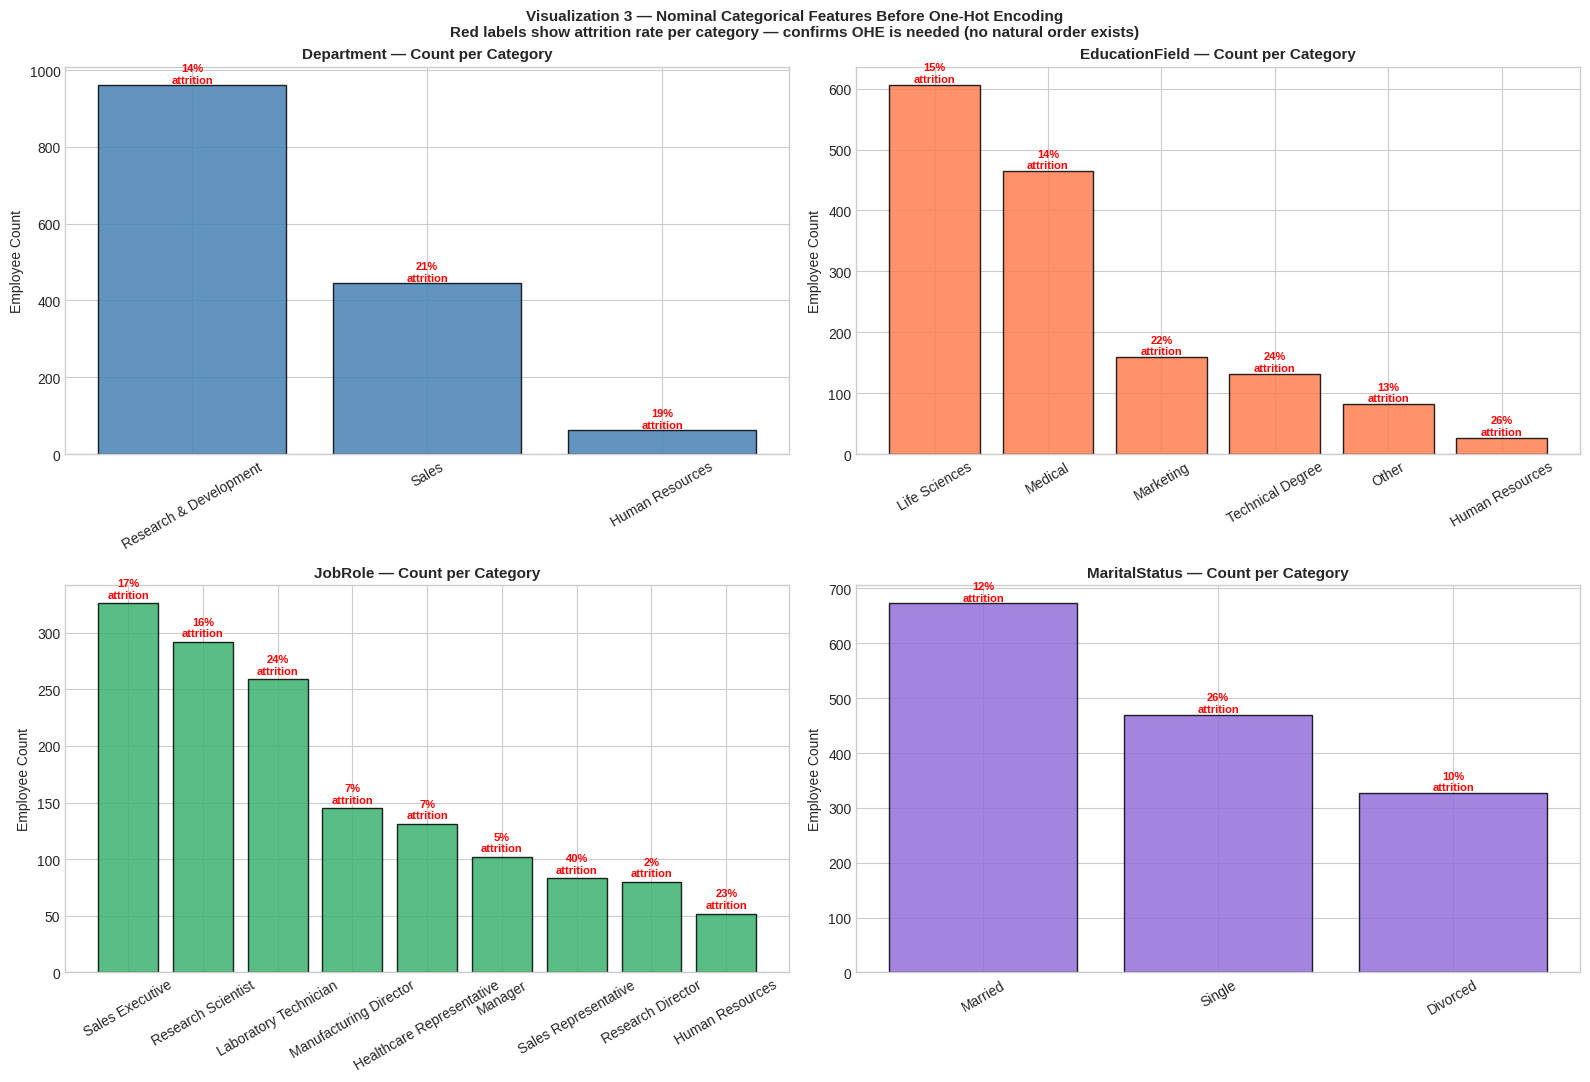

Visualization 3 saved.


In [10]:
# VISUALIZATION 3: Categorical distributions with attrition rate overlay
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for i, col in enumerate(ohe_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col} — Count per Category', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Employee Count')
    axes[i].tick_params(axis='x', rotation=30)
    # Overlay attrition rate as red percentage label
    for j, cat in enumerate(counts.index):
        rate = df[df[col] == cat]['Attrition'].mean() * 100
        axes[i].text(j, counts[cat] + 5, f'{rate:.0f}%\nattrition',
                     ha='center', fontsize=8, color='red', fontweight='bold')

plt.suptitle(
    'Visualization 3 — Nominal Categorical Features Before One-Hot Encoding\n'
    'Red labels show attrition rate per category — confirms OHE is needed (no natural order exists)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz3_categorical_before_ohe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 3 saved.')

In [11]:
# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

new_ohe_cols = [c for c in df.columns if any(c.startswith(p + '_') for p in ohe_cols)]

print(f'One-Hot Encoding applied.')
print(f'New binary columns created ({len(new_ohe_cols)}):')
for col in new_ohe_cols:
    print(f'  {col}: unique values = {sorted(df[col].unique())}')
print(f'\nDataset shape after OHE: {df.shape}')

One-Hot Encoding applied.
New binary columns created (21):
  Department_Human Resources: unique values = [np.False_, np.True_]
  Department_Research & Development: unique values = [np.False_, np.True_]
  Department_Sales: unique values = [np.False_, np.True_]
  EducationField_Human Resources: unique values = [np.False_, np.True_]
  EducationField_Life Sciences: unique values = [np.False_, np.True_]
  EducationField_Marketing: unique values = [np.False_, np.True_]
  EducationField_Medical: unique values = [np.False_, np.True_]
  EducationField_Other: unique values = [np.False_, np.True_]
  EducationField_Technical Degree: unique values = [np.False_, np.True_]
  JobRole_Healthcare Representative: unique values = [np.False_, np.True_]
  JobRole_Human Resources: unique values = [np.False_, np.True_]
  JobRole_Laboratory Technician: unique values = [np.False_, np.True_]
  JobRole_Manager: unique values = [np.False_, np.True_]
  JobRole_Manufacturing Director: unique values = [np.False_, np.

---
## 5. NUMERICAL DATA — Scaling / Normalization

**Why we scale continuous features:**  
Many machine learning algorithms are sensitive to the scale of input features:
- **SVM** uses distances between points — a feature with range 1–20,000 (MonthlyIncome) would completely dominate a feature with range 1–5 (JobLevel) without scaling.
- **KNN** computes Euclidean distance — same problem as SVM.
- **Neural Networks** converge much faster and more reliably when inputs are on the same scale.
- **Logistic Regression** is affected by feature magnitude when regularization is applied.

**Why StandardScaler specifically?**  
StandardScaler transforms each feature to have **mean = 0 and standard deviation = 1**. This is appropriate here because the features are not perfectly normally distributed, but the z-score transformation preserves the shape of each distribution while putting all features on the same scale.

**Why not MinMaxScaler?**  
MinMaxScaler is sensitive to outliers — a single extreme value compresses all other values into a small range. Since outlier handling is done by Student B after scaling, StandardScaler is the safer choice.

In [12]:
# Identify continuous numeric columns to scale
# Exclude: target (Attrition), OHE columns, and low-cardinality ordinal columns
exclude_from_scaling = ['Attrition'] + new_ohe_cols
low_cardinality = [c for c in df.select_dtypes(include=[np.number]).columns
                   if df[c].nunique() <= 5 and c not in exclude_from_scaling]
continuous_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                   if c not in exclude_from_scaling and c not in low_cardinality]

print(f'Columns to scale ({len(continuous_cols)}):')
for c in continuous_cols:
    print(f'  {c}: min={df[c].min():.1f}, max={df[c].max():.1f}, mean={df[c].mean():.1f}')

Columns to scale (14):
  Age: min=18.0, max=60.0, mean=36.9
  DailyRate: min=102.0, max=1499.0, mean=802.5
  DistanceFromHome: min=1.0, max=29.0, mean=9.2
  HourlyRate: min=30.0, max=100.0, mean=65.9
  MonthlyIncome: min=1009.0, max=19999.0, mean=6502.9
  MonthlyRate: min=2094.0, max=26999.0, mean=14313.1
  NumCompaniesWorked: min=0.0, max=9.0, mean=2.7
  PercentSalaryHike: min=11.0, max=25.0, mean=15.2
  TotalWorkingYears: min=0.0, max=40.0, mean=11.3
  TrainingTimesLastYear: min=0.0, max=6.0, mean=2.8
  YearsAtCompany: min=0.0, max=40.0, mean=7.0
  YearsInCurrentRole: min=0.0, max=18.0, mean=4.2
  YearsSinceLastPromotion: min=0.0, max=15.0, mean=2.2
  YearsWithCurrManager: min=0.0, max=17.0, mean=4.1


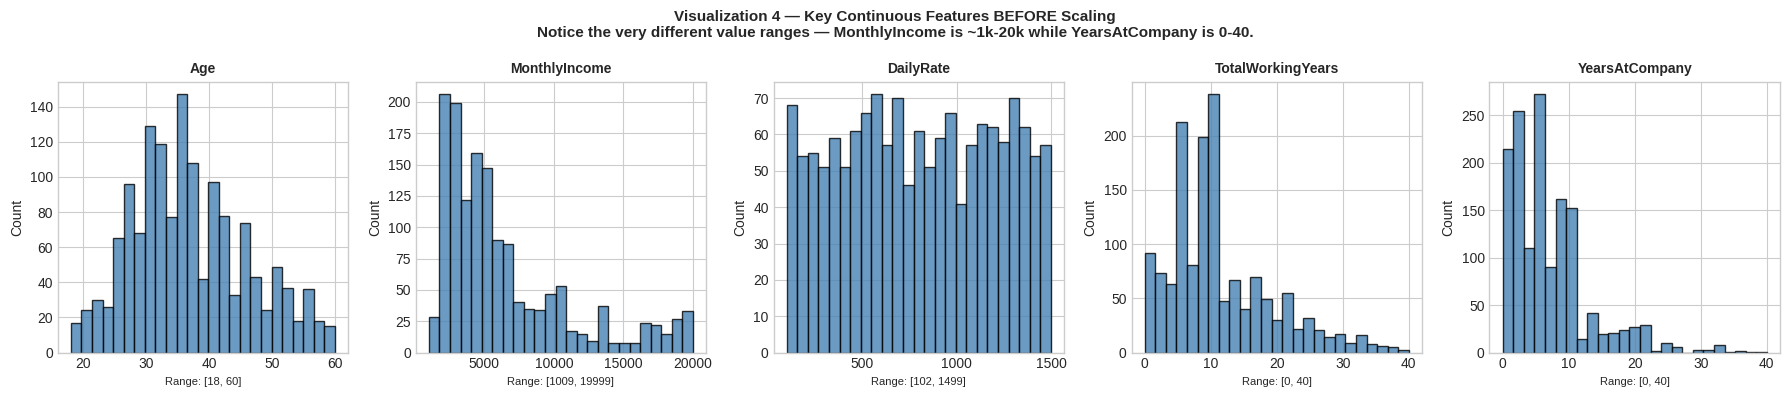

Visualization 4 saved.


In [13]:
# VISUALIZATION 4: Before scaling — key continuous features
key_cols = ['Age', 'MonthlyIncome', 'DailyRate', 'TotalWorkingYears', 'YearsAtCompany']

fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 4))
for i, col in enumerate(key_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel(f'Range: [{df[col].min():.0f}, {df[col].max():.0f}]', fontsize=8)
    axes[i].set_ylabel('Count')
plt.suptitle(
    'Visualization 4 — Key Continuous Features BEFORE Scaling\n'
    'Notice the very different value ranges — MonthlyIncome is ~1k-20k while YearsAtCompany is 0-40.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz4_before_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 4 saved.')

In [14]:
# Apply StandardScaler
scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print('StandardScaler applied.')
print('\nVerification — mean and std after scaling:')
for c in continuous_cols:
    print(f'  {c}: mean={df[c].mean():.4f} (should be ~0), std={df[c].std():.4f} (should be ~1)')

StandardScaler applied.

Verification — mean and std after scaling:
  Age: mean=-0.0000 (should be ~0), std=1.0003 (should be ~1)
  DailyRate: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  DistanceFromHome: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  HourlyRate: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  MonthlyIncome: mean=-0.0000 (should be ~0), std=1.0003 (should be ~1)
  MonthlyRate: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  NumCompaniesWorked: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  PercentSalaryHike: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  TotalWorkingYears: mean=-0.0000 (should be ~0), std=1.0003 (should be ~1)
  TrainingTimesLastYear: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  YearsAtCompany: mean=-0.0000 (should be ~0), std=1.0003 (should be ~1)
  YearsInCurrentRole: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  YearsSinceLastPromotion: mean=0.0000 (should be ~0), std=1.0003

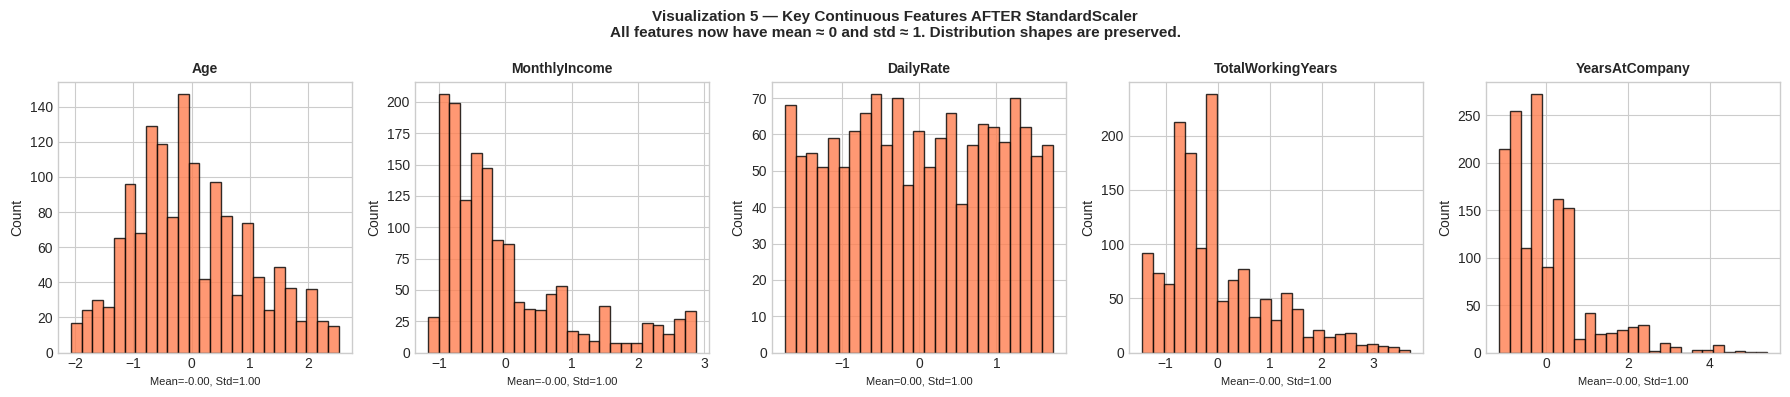

Visualization 5 saved.


In [15]:
# VISUALIZATION 5: After scaling — same features now on same scale
fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 4))
for i, col in enumerate(key_cols):
    axes[i].hist(df[col], bins=25, color='coral', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel(f'Mean={df[col].mean():.2f}, Std={df[col].std():.2f}', fontsize=8)
    axes[i].set_ylabel('Count')
plt.suptitle(
    'Visualization 5 — Key Continuous Features AFTER StandardScaler\n'
    'All features now have mean ≈ 0 and std ≈ 1. Distribution shapes are preserved.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz5_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 5 saved.')

---
## 6. NEW FEATURES — Ratio Features

**Why create new features?**  
Raw features sometimes hide important relationships. Ratio features capture the *relationship between two variables*, which can be far more predictive than either variable alone. For example, an employee who has not been promoted in 3 years at a company where they have worked for 4 years tells a very different story than someone who has not been promoted in 3 years but has only worked there for 3 years.

**Features created and their reasoning:**

| New Feature | Formula | Why it matters |
|-------------|---------|----------------|
| `PromotionRatio` | YearsSinceLastPromotion / (YearsAtCompany + 1) | Measures career stagnation relative to tenure. High value = employee has waited a long time for promotion → strong attrition signal |
| `IncomePerYear` | MonthlyIncome / (TotalWorkingYears + 1) | Measures whether pay matches experience. Low value = underpaid for experience → salary dissatisfaction risk |
| `RoleStabilityRatio` | YearsInCurrentRole / (YearsAtCompany + 1) | Measures how long someone has stayed in the same role relative to total tenure. Very low = frequent role changes; very high = stuck in same role |

> **Note:** We add +1 to all denominators to prevent division-by-zero for new employees with 0 years at the company.

In [16]:
# Use raw values from df_raw for ratio calculations (before scaling distorts the values)
df['PromotionRatio']    = df_raw['YearsSinceLastPromotion'] / (df_raw['YearsAtCompany'] + 1)
df['IncomePerYear']     = df_raw['MonthlyIncome']           / (df_raw['TotalWorkingYears'] + 1)
df['RoleStabilityRatio']= df_raw['YearsInCurrentRole']      / (df_raw['YearsAtCompany'] + 1)

ratio_cols = ['PromotionRatio', 'IncomePerYear', 'RoleStabilityRatio']

print('Ratio features created:')
for col in ratio_cols:
    attr_mean    = df[df['Attrition'] == 1][col].mean()
    no_attr_mean = df[df['Attrition'] == 0][col].mean()
    print(f'  {col}:')
    print(f'    Mean (Attrition=1): {attr_mean:.3f}')
    print(f'    Mean (Attrition=0): {no_attr_mean:.3f}')
    print(f'    Difference: {abs(attr_mean - no_attr_mean):.3f} — {"good signal" if abs(attr_mean - no_attr_mean) > 0.05 else "weak signal"}')

Ratio features created:
  PromotionRatio:
    Mean (Attrition=1): 0.243
    Mean (Attrition=0): 0.235
    Difference: 0.008 — weak signal
  IncomePerYear:
    Mean (Attrition=1): 651.007
    Mean (Attrition=0): 575.383
    Difference: 75.624 — good signal
  RoleStabilityRatio:
    Mean (Attrition=1): 0.382
    Mean (Attrition=0): 0.500
    Difference: 0.117 — good signal


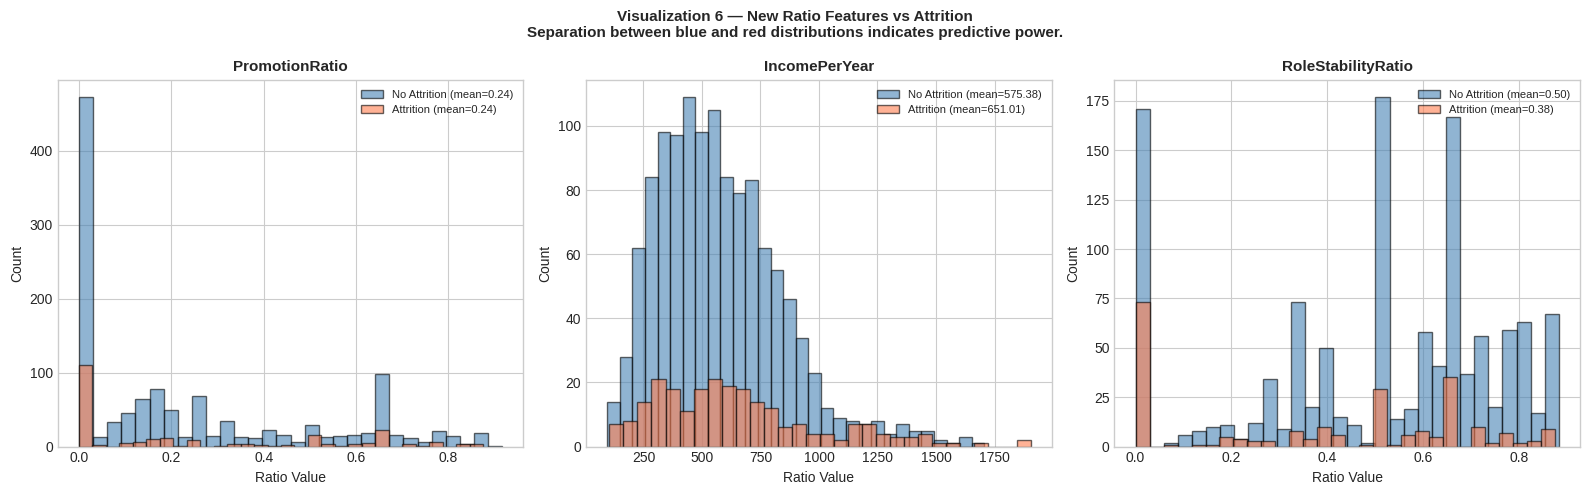

Visualization 6 saved.


In [17]:
# VISUALIZATION 6: Ratio features by Attrition group
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(ratio_cols):
    no_attr  = df[df['Attrition'] == 0][col]
    yes_attr = df[df['Attrition'] == 1][col]
    axes[i].hist(no_attr,  bins=30, alpha=0.6, color='steelblue', edgecolor='black', label=f'No Attrition (mean={no_attr.mean():.2f})')
    axes[i].hist(yes_attr, bins=30, alpha=0.6, color='coral',     edgecolor='black', label=f'Attrition (mean={yes_attr.mean():.2f})')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Ratio Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle(
    'Visualization 6 — New Ratio Features vs Attrition\n'
    'Separation between blue and red distributions indicates predictive power.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz6_ratio_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 6 saved.')

---
## 7. VISUALIZATIONS — Exploratory Analysis

**Why these visualizations?**  
The project requires the Preprocessing & Visualization Team to produce visualizations that help understand the data and justify preprocessing decisions. The following plots serve specific analytical purposes:
- The **correlation heatmap** identifies which features are most related to attrition, guiding feature selection in Part B.
- The **box plots** show how the top features differ between employees who left vs. stayed.
- The **JobRole attrition chart** shows which roles carry the highest turnover risk, validating our OHE decision.

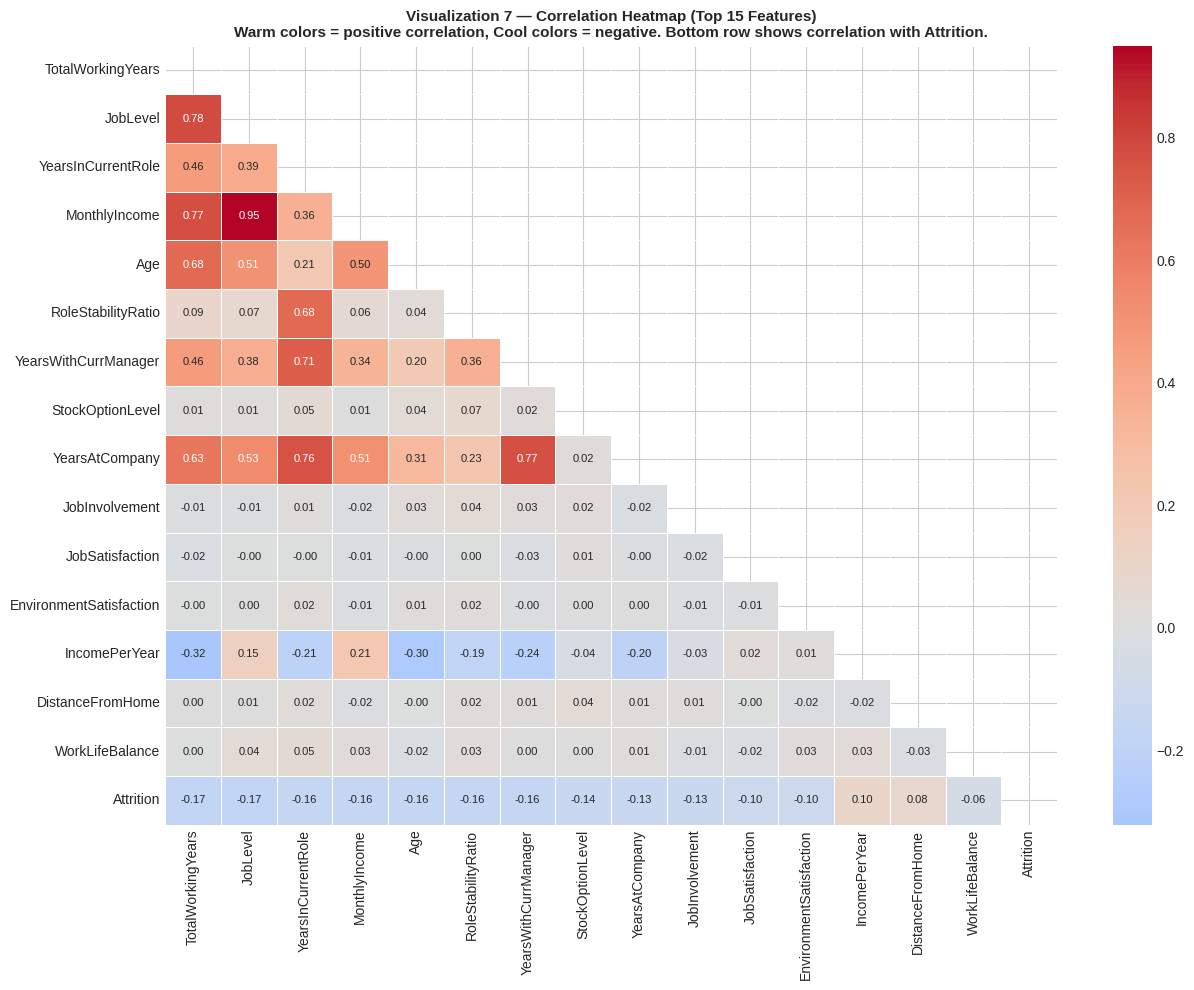

Visualization 7 saved.


In [18]:
# VISUALIZATION 7: Correlation Heatmap — top features correlated with Attrition
numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()['Attrition'].drop('Attrition').abs().sort_values(ascending=False)
top15 = corr_with_target.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(13, 10))
corr_matrix = numeric_df[top15 + ['Attrition']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, mask=mask, linewidths=0.5, annot_kws={'size': 8})
ax.set_title(
    'Visualization 7 — Correlation Heatmap (Top 15 Features)\n'
    'Warm colors = positive correlation, Cool colors = negative. Bottom row shows correlation with Attrition.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 7 saved.')

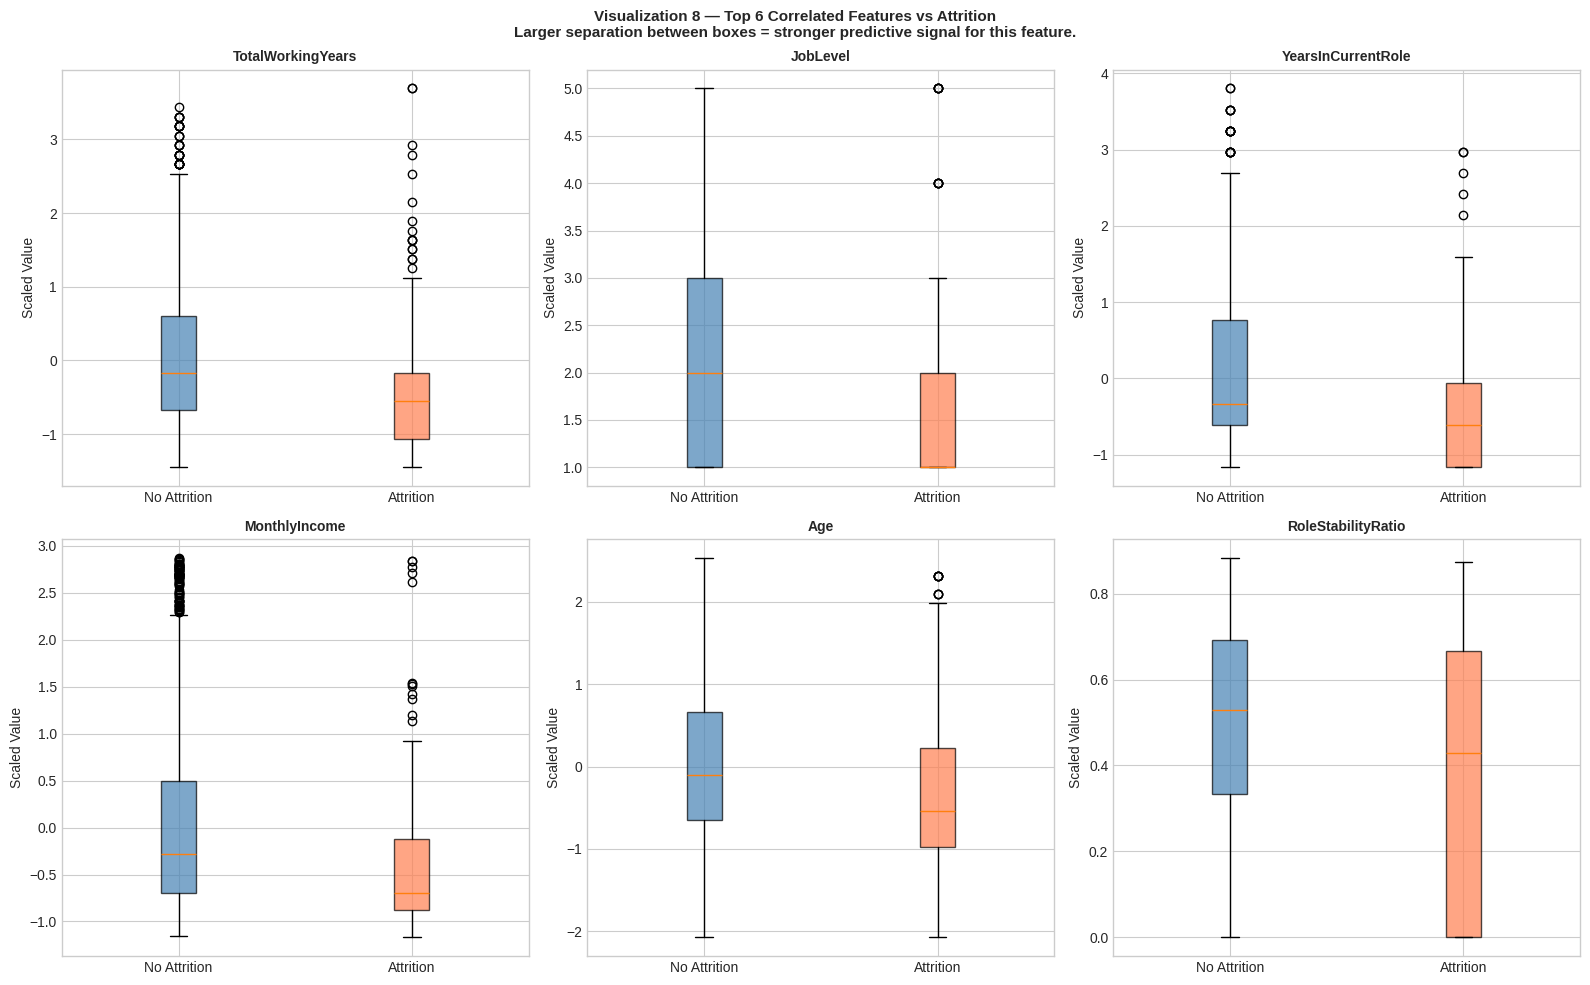

Visualization 8 saved.


In [19]:
# VISUALIZATION 8: Top 6 features vs Attrition — Box Plots
top6 = corr_with_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    bp = axes[i].boxplot(
        [df[df['Attrition'] == 0][col], df[df['Attrition'] == 1][col]],
        labels=['No Attrition', 'Attrition'],
        patch_artist=True
    )
    bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('coral');     bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Scaled Value')

plt.suptitle(
    'Visualization 8 — Top 6 Correlated Features vs Attrition\n'
    'Larger separation between boxes = stronger predictive signal for this feature.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz8_top_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 8 saved.')

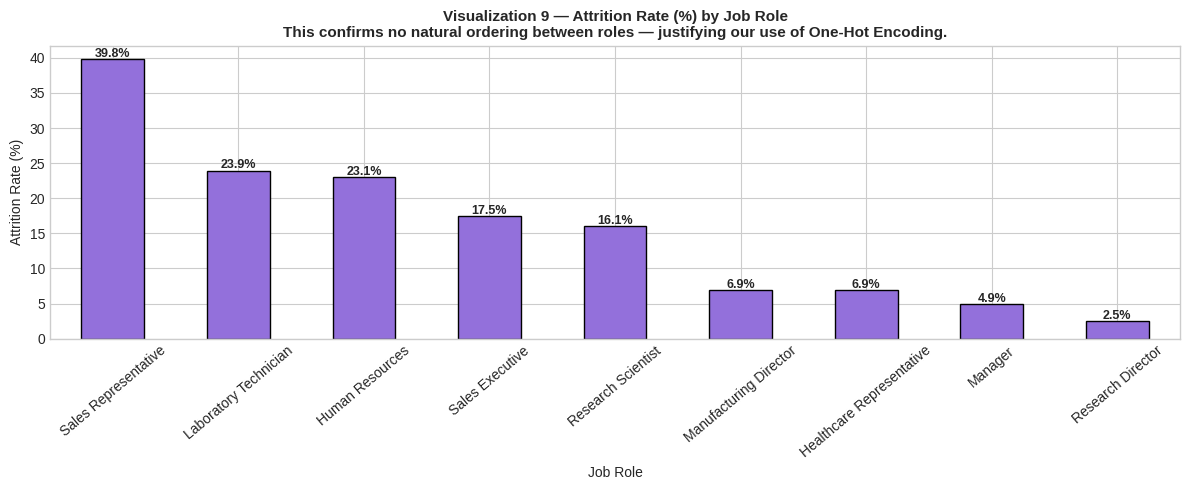

Visualization 9 saved.


In [20]:
# VISUALIZATION 9: Attrition rate by JobRole (using OHE output)
jobrole_attrition = {
    col.replace('JobRole_', ''): df[df[col] == 1]['Attrition'].mean() * 100
    for col in df.columns if col.startswith('JobRole_')
}
jobrole_series = pd.Series(jobrole_attrition).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = jobrole_series.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title(
    'Visualization 9 — Attrition Rate (%) by Job Role\n'
    'This confirms no natural ordering between roles — justifying our use of One-Hot Encoding.',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Job Role')
ax.set_ylabel('Attrition Rate (%)')
ax.tick_params(axis='x', rotation=40)
for i, v in enumerate(jobrole_series.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/viz9_jobrole_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 9 saved.')

---
## 8. Save Output



In [21]:
output_filename = 'part1_output.csv'
df.to_csv(output_filename, index=False)

print(f'Output saved: {output_filename}')
print(f'Shape: {df.shape}')
print(f'\nColumns still as text:')
for col in df.select_dtypes(include='object').columns:
    print(f'  {col}: {df[col].unique()}')

df.head()

Output saved: StudentA_output.csv
Shape: (1470, 51)

Columns still as text (Student B will encode these):
  BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
  Gender: ['Female' 'Male']
  OverTime: ['Yes' 'No']


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,PromotionRatio,IncomePerYear,RoleStabilityRatio
0,0.446350,1,Travel_Rarely,0.742527,-1.010909,2,2,Female,1.383138,3,2,4,-0.108350,0.726020,2.125136,Yes,-1.150554,3,1,0,-0.421642,-2.171982,1,-0.164613,-0.063296,-0.679146,0.245834,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,0.000000,665.888889,0.571429
1,1.322365,0,Travel_Frequently,-1.297775,-0.147150,1,3,Male,-0.240677,2,2,2,-0.291719,1.488876,-0.678049,No,2.129306,4,4,1,-0.164511,0.155707,3,0.488508,0.764998,-0.368715,0.806541,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,0.090909,466.363636,0.636364
2,0.008343,1,Travel_Rarely,1.414363,-0.887515,2,4,Male,1.284725,2,1,3,-0.937654,-1.674841,1.324226,Yes,-0.057267,3,2,0,-0.550208,0.155707,3,-1.144294,-1.167687,-0.679146,-1.155935,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,0.000000,261.250000,0.000000
3,-0.429664,0,Travel_Frequently,1.461466,-0.764121,4,4,Female,-0.486709,3,1,3,-0.763634,1.243211,-0.678049,Yes,-1.150554,3,3,0,-0.421642,0.155707,3,0.161947,0.764998,0.252146,-1.155935,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,0.333333,323.222222,0.777778
4,-1.086676,0,Travel_Rarely,-0.524295,-0.887515,1,1,Male,-1.274014,3,1,2,-0.644858,0.325900,2.525591,No,-0.877232,3,4,1,-0.678774,0.155707,3,-0.817734,-0.615492,-0.058285,-0.595227,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,0.666667,495.428571,0.666667


In [22]:
from google.colab import files
files.download(output_filename)
print('Download started! Send StudentA_output.csv to Student B.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Send StudentA_output.csv to Student B.


---
## 9. Key Insights & Challenges

### Key Insights

1. **4 useless columns removed** — `EmployeeCount`, `Over18`, `StandardHours`, and `EmployeeNumber` all had zero predictive value. Keeping them would only add noise to the model.

2. **Dataset is clean but imbalanced** — No missing values were found. However, only 16.1% of employees have `Attrition = Yes`. This class imbalance means a naive model could achieve 84% accuracy by simply always predicting 'No'. We must address this in Part B using stratified k-fold cross-validation and class weights.

3. **OHE was the correct choice for JobRole and Department** — Visualization 9 confirms that attrition rates vary in a non-ordinal pattern across job roles (e.g., Sales Representatives have 40% attrition while Research Directors have ~2.5%). There is no numeric ordering that could represent this correctly.

4. **Ratio features reveal meaningful patterns** — Employees who left had a higher `PromotionRatio` on average, suggesting career stagnation is a driver of attrition. The `IncomePerYear` ratio was lower for employees who left, supporting the salary dissatisfaction hypothesis.

5. **Scaling revealed large range differences** — Before scaling, `MonthlyIncome` ranged from ~1,000 to ~20,000 while `JobLevel` ranged from 1 to 5. Without StandardScaler, distance-based models like SVM and KNN would have been completely dominated by income.

### Challenges

1. **Class imbalance** will require careful handling in Part B to avoid misleading accuracy scores.
2. **Ratio feature interpretation** — ratio values are affected by Student A's scaling of the denominator variables, so we used `df_raw` values to keep ratios meaningful.
3. **Feature explosion from OHE** — `JobRole` alone created 9 new columns. This increases dimensionality, which may be addressed in Phase 2 with PCA or feature selection.

---
## 10. Preprocessing Summary

| Step | Columns Affected | Action | Method | Justification |
|------|-----------------|--------|--------|---------------|
| Drop useless | EmployeeCount, Over18, StandardHours, EmployeeNumber | Remove | Manual drop | Zero variance / unique ID — no predictive value |
| Missing values | All | Confirmed zero | Visual heatmap | IBM synthetic dataset is complete |
| Target encoding | Attrition | Yes→1, No→0 | Manual map | Explicit mapping avoids alphabetical ambiguity |
| One-Hot Encoding | Department, EducationField, JobRole, MaritalStatus | Create dummy columns | pd.get_dummies | No natural order between nominal categories |
| Scaling | All continuous numeric features | Zero mean, unit std | StandardScaler | Prevents magnitude dominance in SVM, KNN, Neural Nets |
| Ratio Features | YearsSinceLastPromotion, MonthlyIncome, YearsInCurrentRole | Create 3 new features | Manual formulas | Captures relationships not visible in raw columns |

In [23]:
print('=' * 55)
print('=' * 55)
print(f'  Input:   {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print(f'  Output:  {df.shape[0]} rows x {df.shape[1]} columns')
print(f'  Plots:   9 visualizations saved to /plots/')
print(f'  File:    StudentA_output.csv  →  send to Student B')
print('=' * 55)
print('  Steps completed:')
print('  [1] Dropped 4 constant/ID columns')
print('  [2] Verified zero missing values')
print('  [3] Encoded Attrition target (Yes=1, No=0)')
print('  [4] One-Hot Encoded 4 nominal categorical columns')
print('  [5] StandardScaler applied to continuous features')
print('  [6] Created 3 ratio features')
print('  [7] Generated 9 exploratory visualizations')
print('=' * 55)

  STUDENT A (DATA ARCHITECT) — COMPLETE
  Input:   1470 rows x 35 columns
  Output:  1470 rows x 51 columns
  Plots:   9 visualizations saved to /plots/
  File:    StudentA_output.csv  →  send to Student B
  Steps completed:
  [1] Dropped 4 constant/ID columns
  [2] Verified zero missing values
  [3] Encoded Attrition target (Yes=1, No=0)
  [4] One-Hot Encoded 4 nominal categorical columns
  [5] StandardScaler applied to continuous features
  [6] Created 3 ratio features
  [7] Generated 9 exploratory visualizations
